Yevchyk Oleksii, INF-1

In [1]:
# Standard Libraries
import random
import itertools
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Models
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
 #Ignore user warnings
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", UndefinedMetricWarning)

#Dataset
Data was obtained from Kaggle:
https://www.kaggle.com/datasets/rouseguy/bankbalanced

In [103]:
df = pd.read_csv("/bank.csv")

## Preprocessing
Data clearing

Show data

In [84]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Categorical features — unique values:


```
job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
  marital: ['divorced', 'married', 'single']
  education: ['primary', 'secondary', 'tertiary', 'unknown']
  default: ['no', 'yes']
  housing: ['no', 'yes']
  loan: ['no', 'yes']
  contact: ['cellular', 'telephone', 'unknown']
  month: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
  poutcome: ['failure', 'other', 'success', 'unknown']
[clean] 'job': NaN → мода 'management'
[clean] 'education': NaN → мода 'secondary'
[clean] 'contact': NaN → мода 'cellular'
[clean] 'poutcome': NaN → мода 'failure'
[encode] One-hot: ['job', 'marital', 'contact', 'poutcome']

```



In [86]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


 Check missing values and remove duplicates

In [87]:
df.isnull().values.any()

np.False_

But we have other not empty but not valid data - 'unknown'
function clean:

- Replaces 'unknown' with NaN, then fills in the mode for categorical
and median for numeric.
- Removes duplicates.

In [104]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 'unknown' → NaN
    df.replace("unknown", np.nan, inplace=True)

    # Fill up empty values
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == object:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f"[clean] '{col}': NaN → мода '{mode_val}'")
            else:
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"[clean] '{col}': NaN → медіана {median_val}")

    # Duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    removed = before - len(df)
    if removed:
        print(f"[clean] Видалено {removed} дублікатів")

    return df

In [105]:
df = clean(df)

[clean] 'job': NaN → мода 'management'
[clean] 'education': NaN → мода 'secondary'
[clean] 'contact': NaN → мода 'cellular'
[clean] 'poutcome': NaN → мода 'failure'


/tmp/ipykernel_17990/3963416105.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [106]:
df.shape

(11162, 17)

Distribution of categorical variables

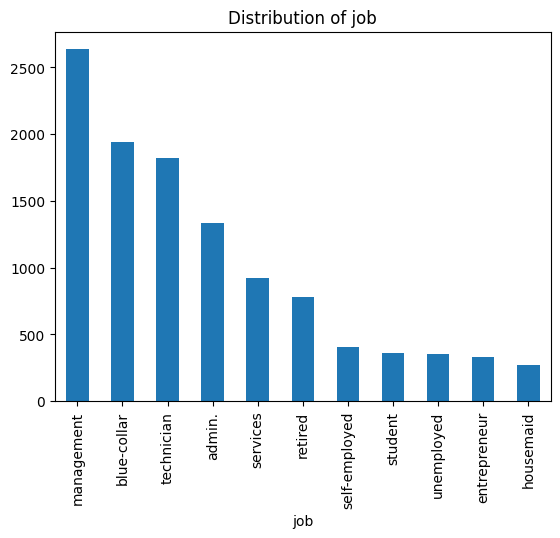

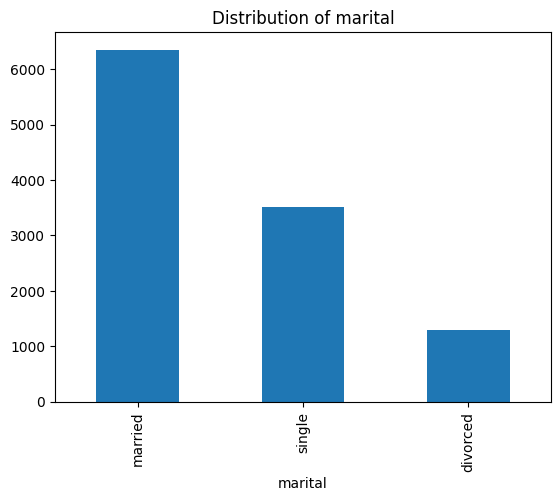

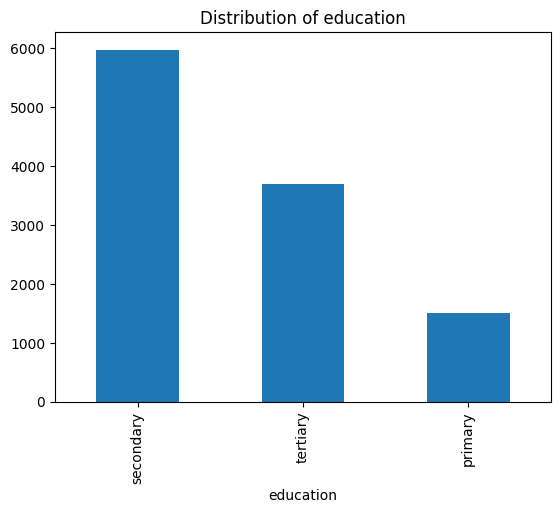

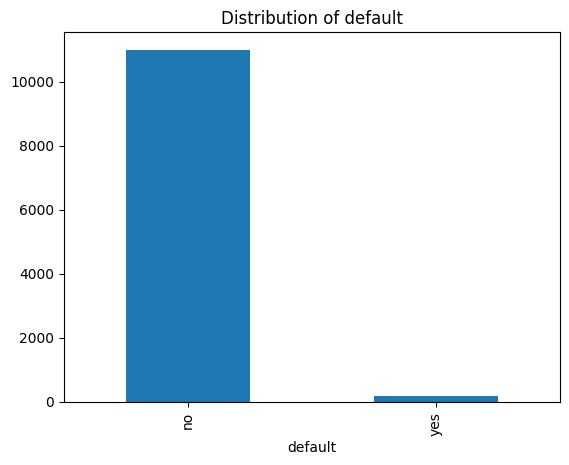

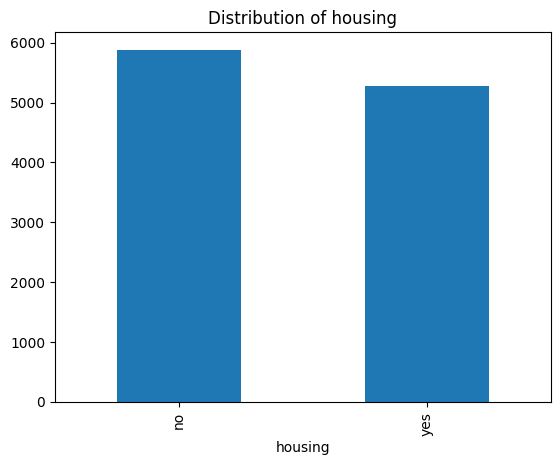

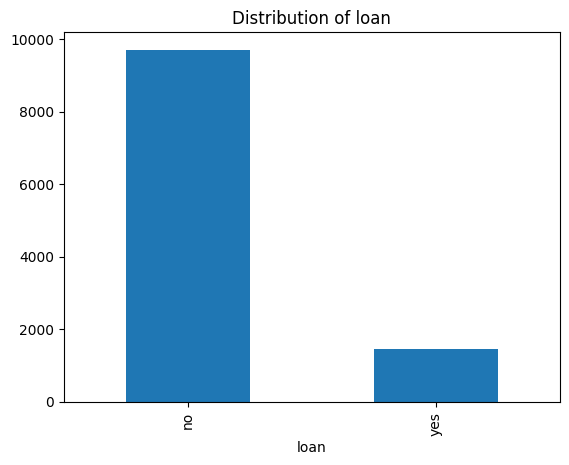

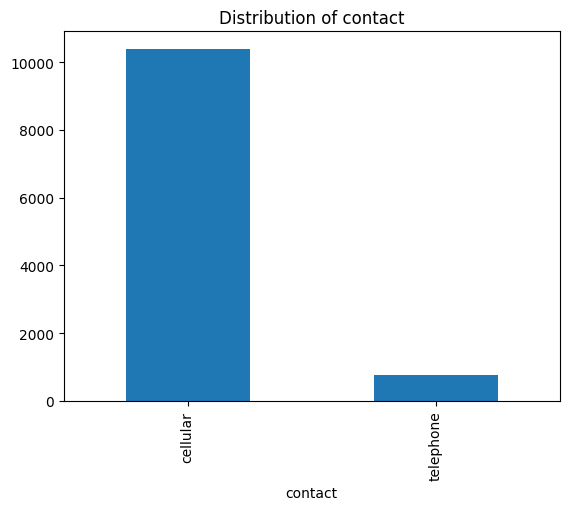

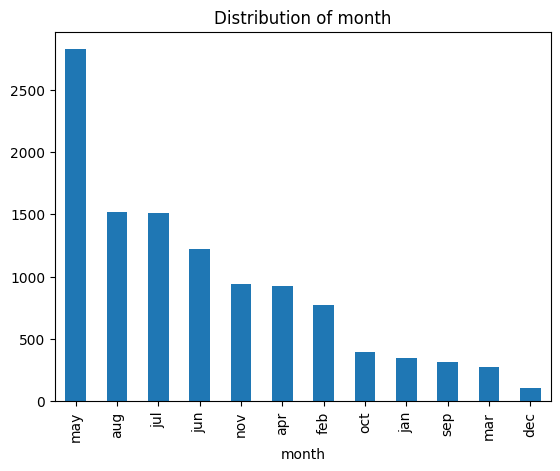

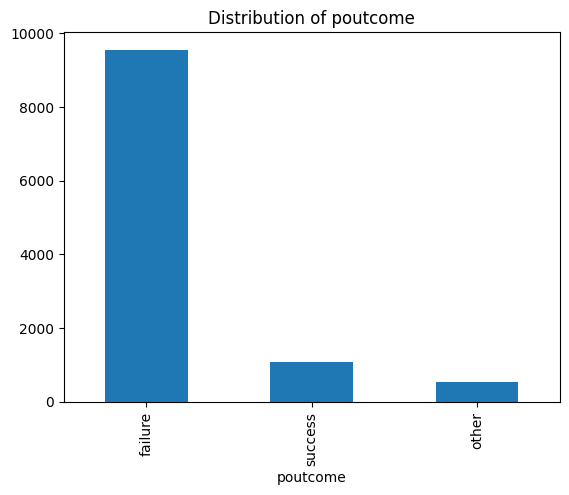

In [107]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int', 'float']).columns

cat_cols.remove('deposit')

for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.show()

Endcoding

"deposit" (target variable) is transformed from yes/no → 1/0.

In [108]:
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0}).astype(int)

The three binary columns with "yes"/"no" also convert to 1/0.

In [109]:
BINARY_COLS = ["default", "housing", "loan"]
for col in BINARY_COLS:
    if col in df.columns:
        df[col] = df[col].map({"yes": 1, "no": 0})

"education" is an example of an ordinal variable: primary < secondary < tertiary.
Converts to the numbers 0, 1, 2.

In [110]:
ORDINAL_EDUCATION = {"primary": 0, "secondary": 1, "tertiary": 2}
if "education" in df.columns:
    df["education"] = df["education"].map(ORDINAL_EDUCATION)

In [111]:
ORDINAL_MONTH = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,  "may": 5,  "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}
if "month" in df.columns:
    df["month"] = df["month"].map(ORDINAL_MONTH)

The rest of the categorical variables → one-hot encoding

In [112]:
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != "deposit"]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

 Train/Val/Test split

*  Train: 72%
*  Val: 8%
*  Test: 20%


In [114]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(y))
    split = int(len(y) * (1 - test_size))
    train_idx, test_idx = idx[:split], idx[split:]
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

In [115]:
X = df.drop(columns=["deposit"])
y = df["deposit"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42
)

## Feature engineering


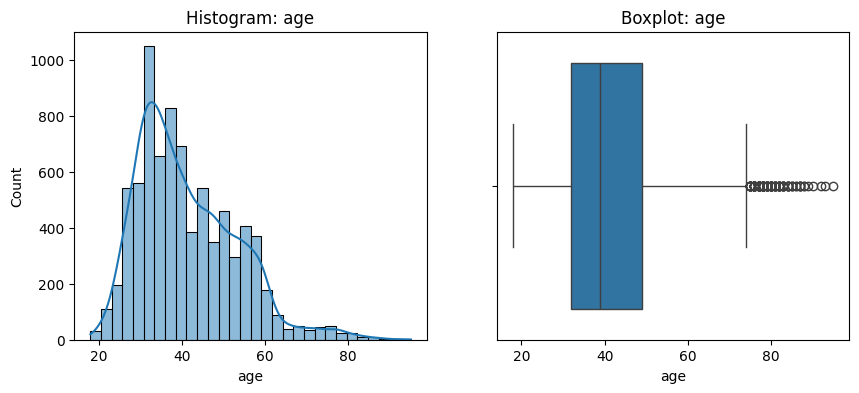

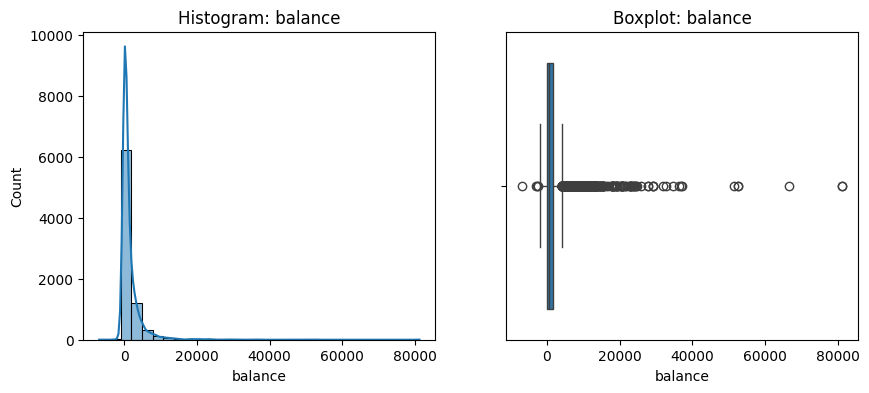

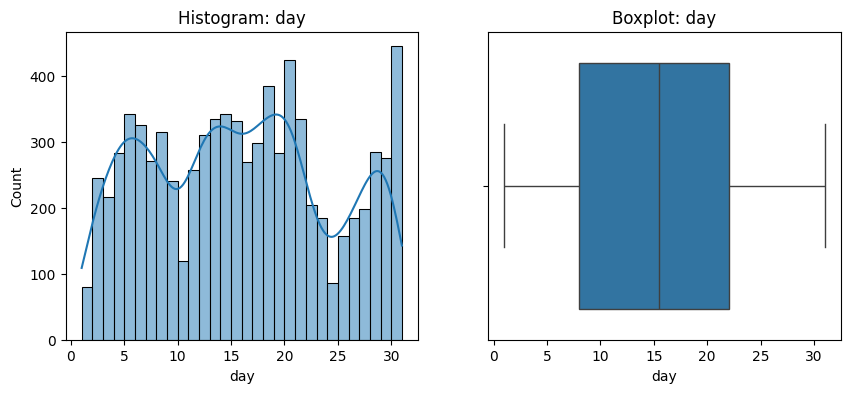

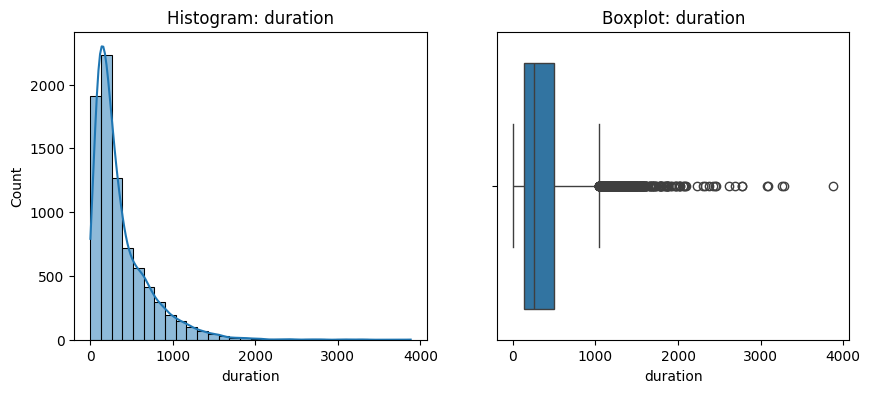

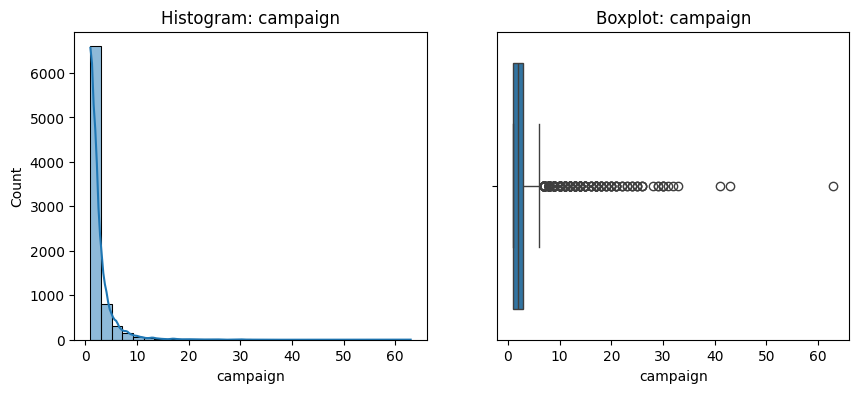

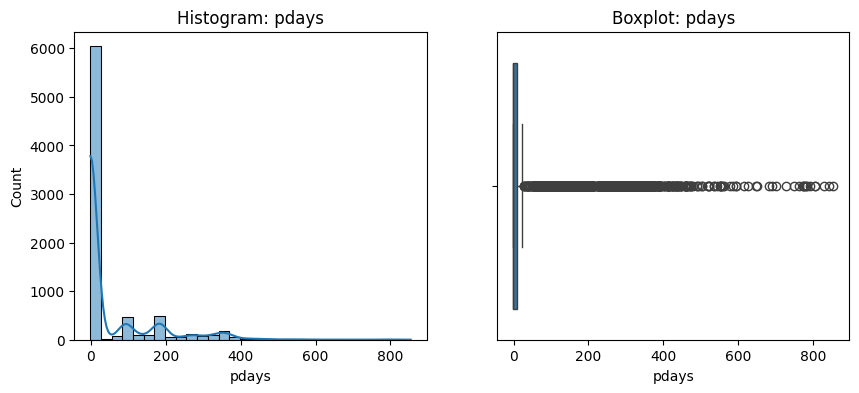

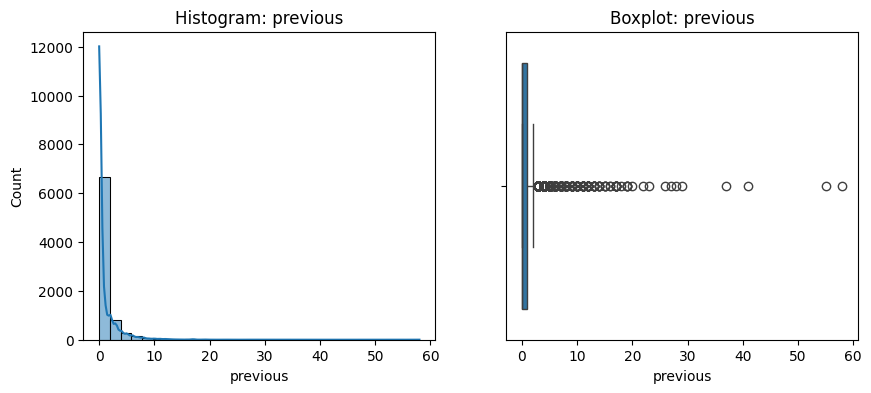

In [117]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f"Histogram: {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot: {col}")

    plt.show()

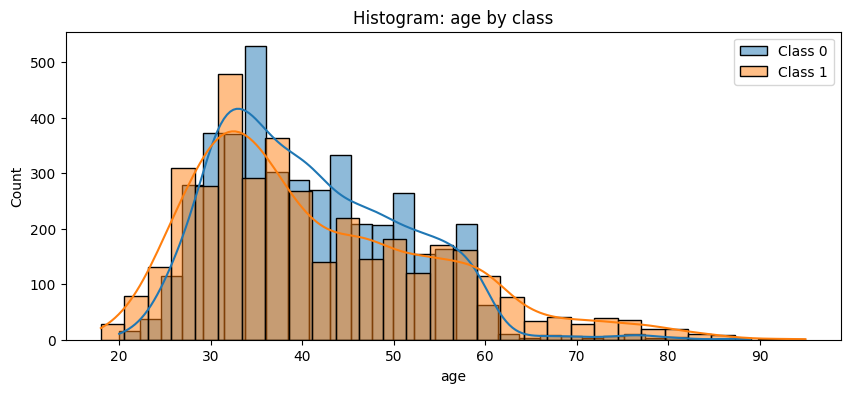

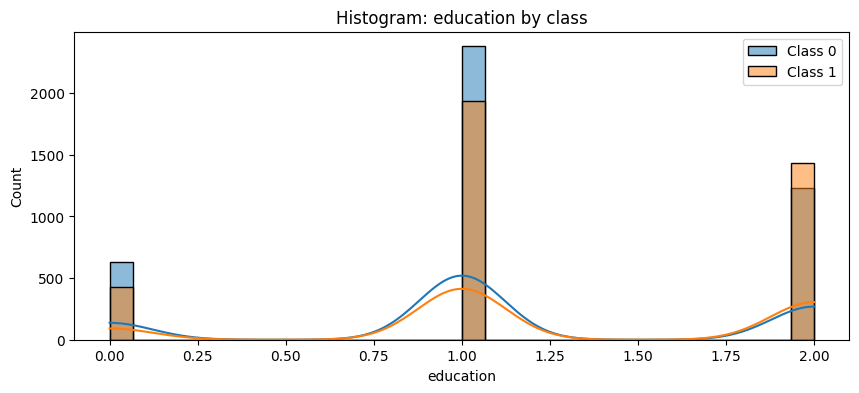

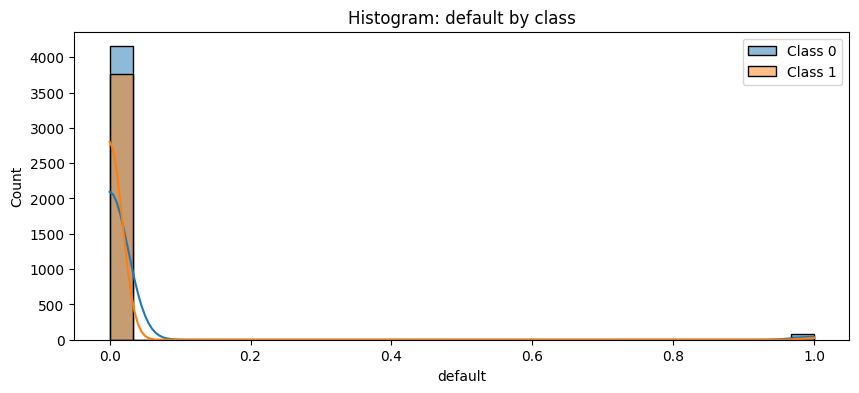

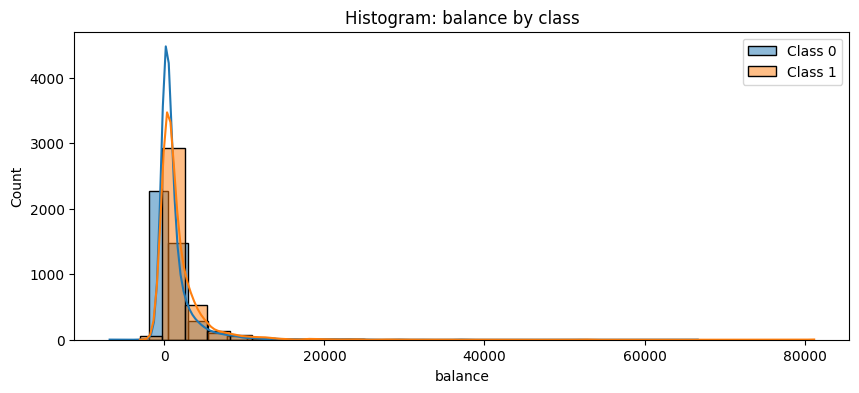

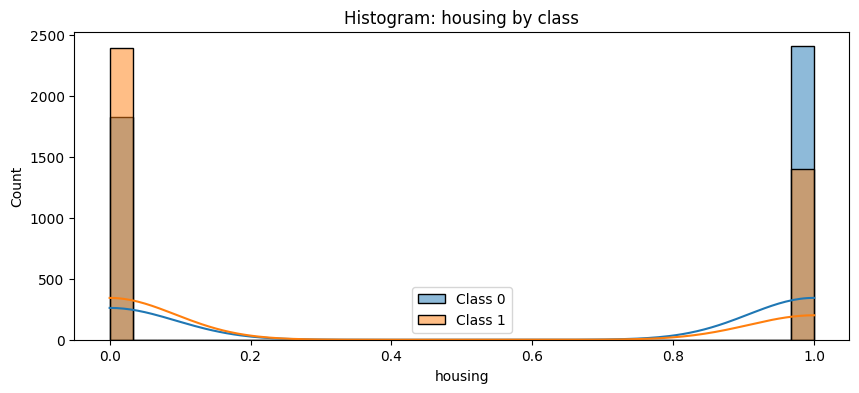

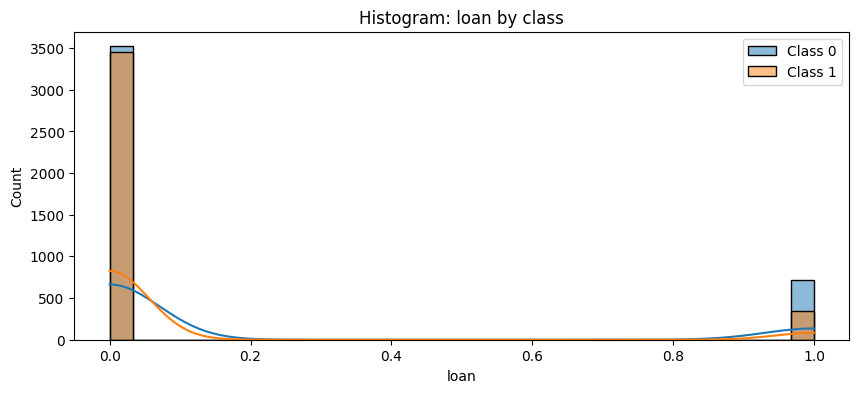

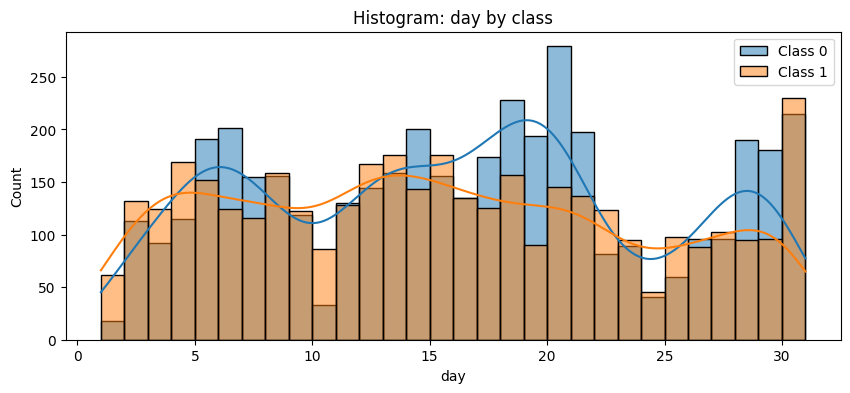

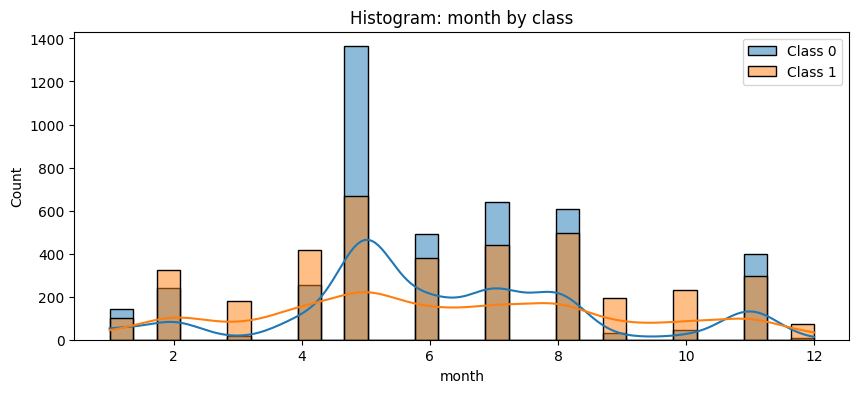

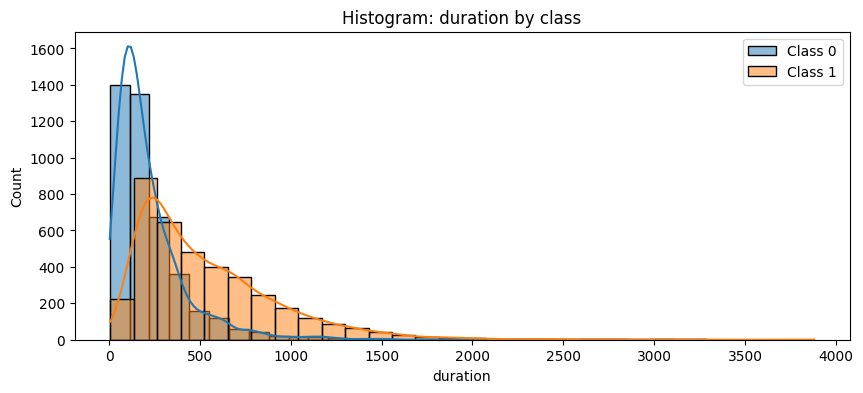

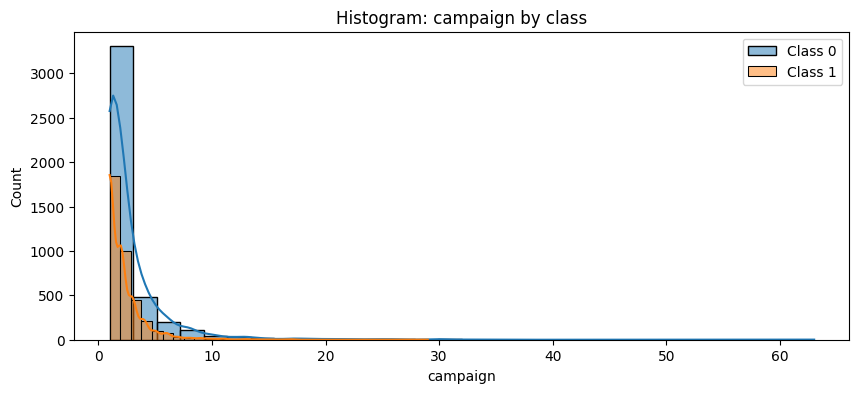

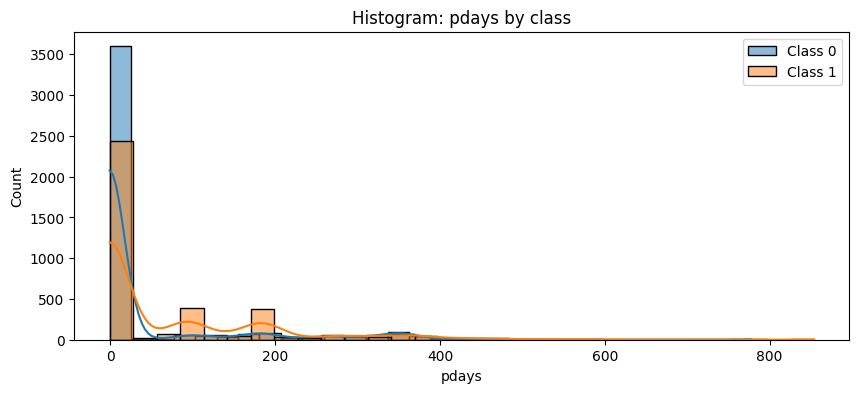

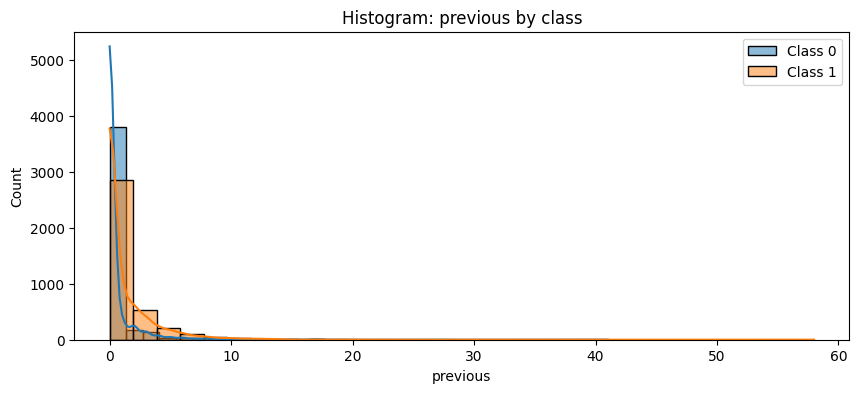

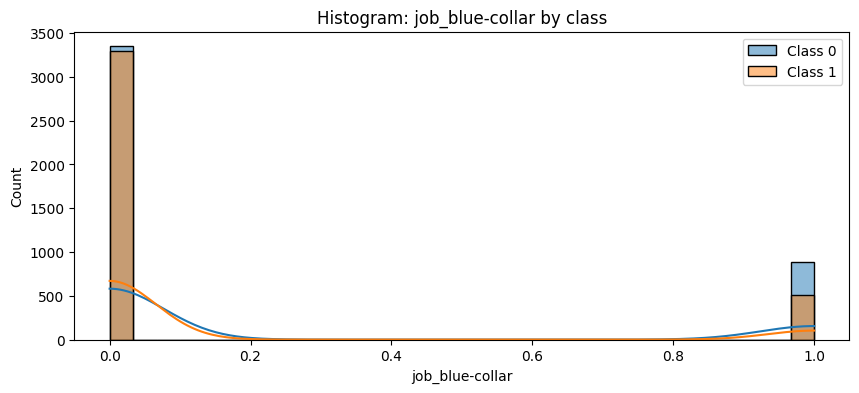

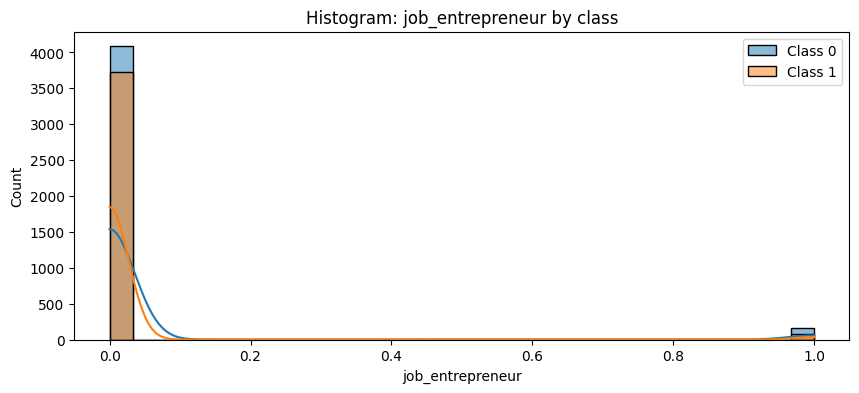

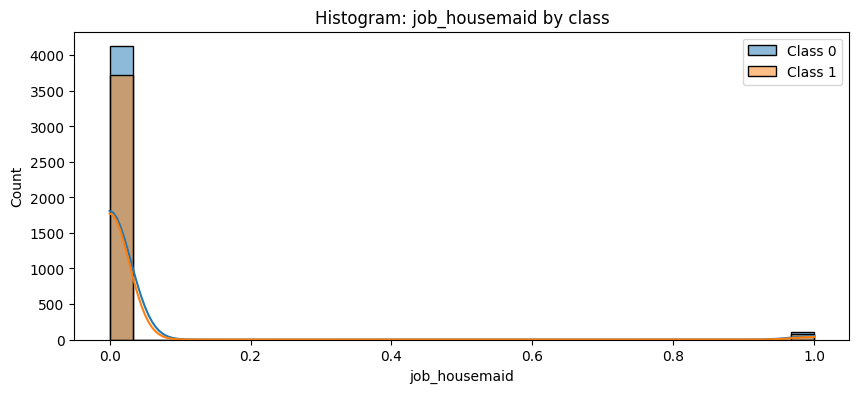

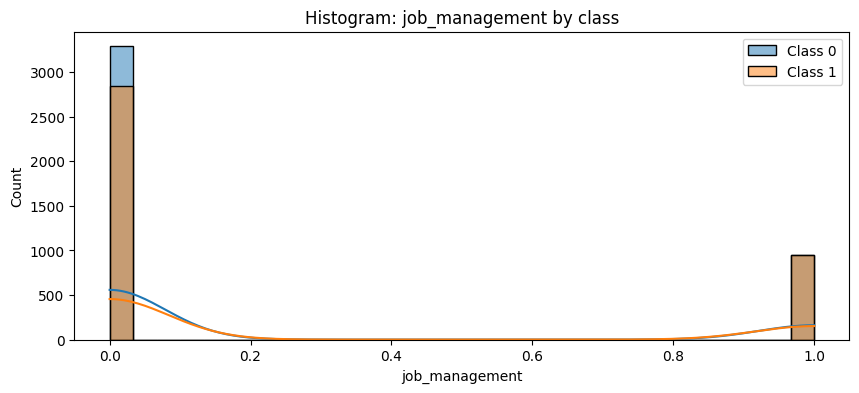

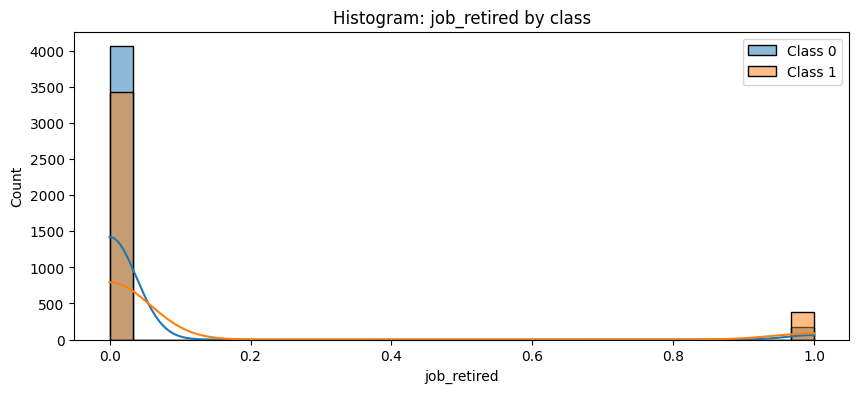

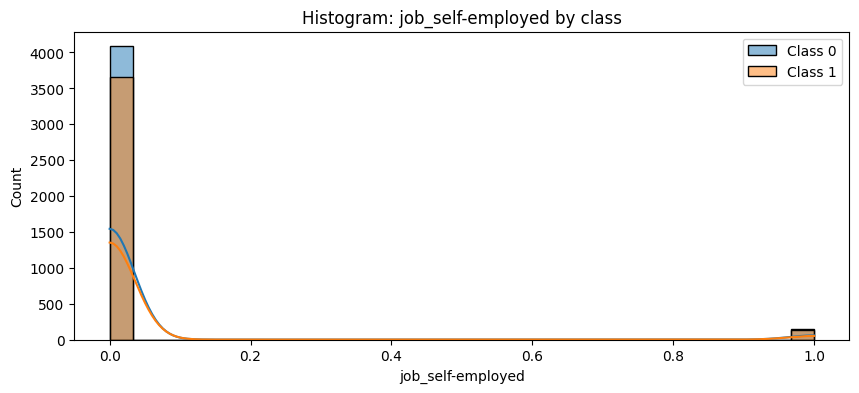

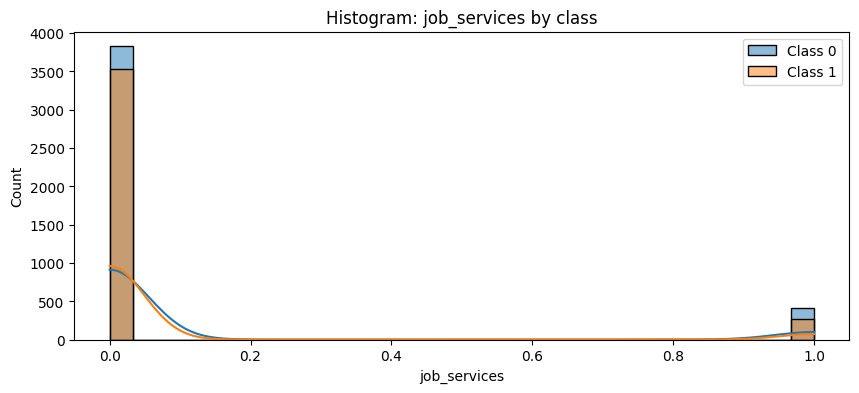

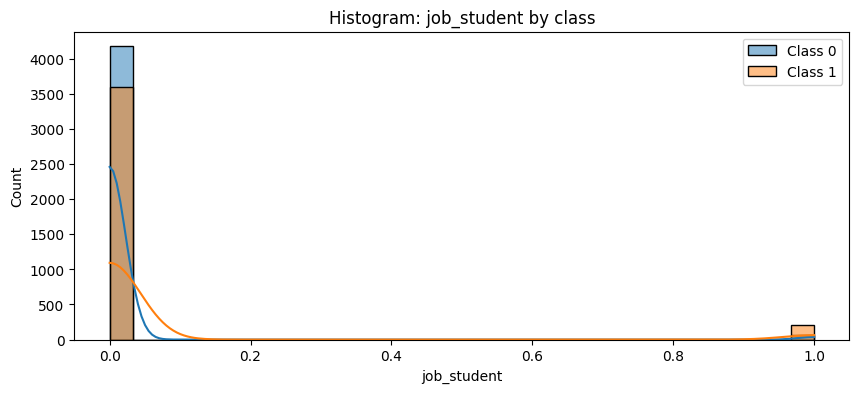

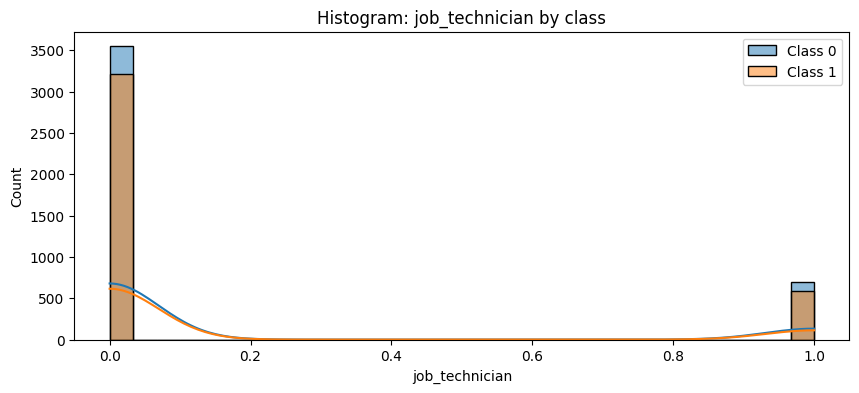

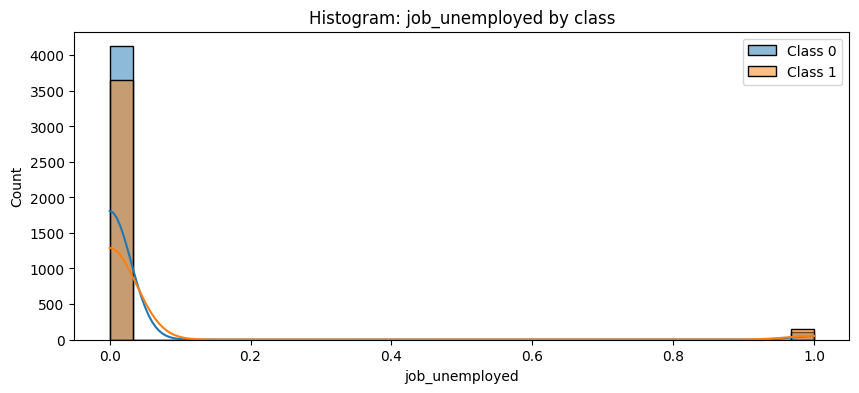

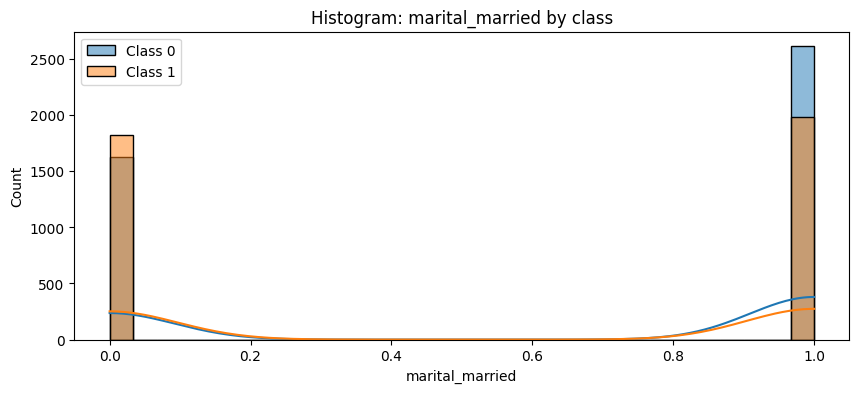

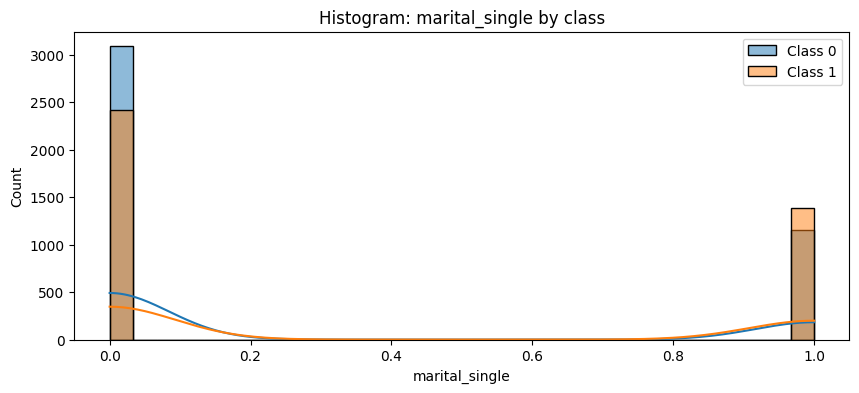

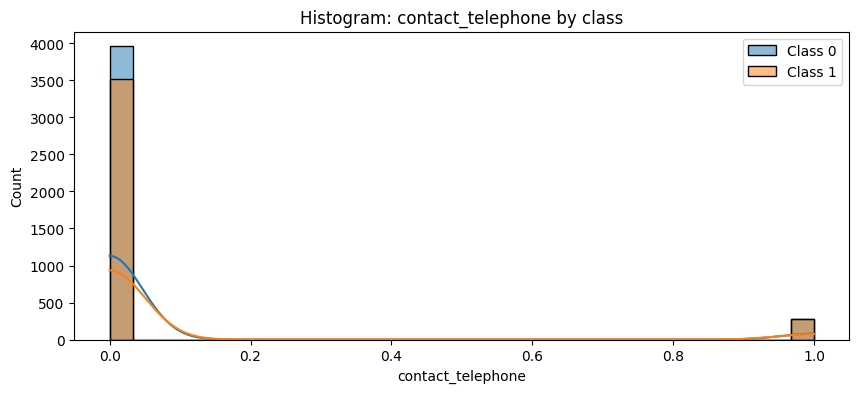

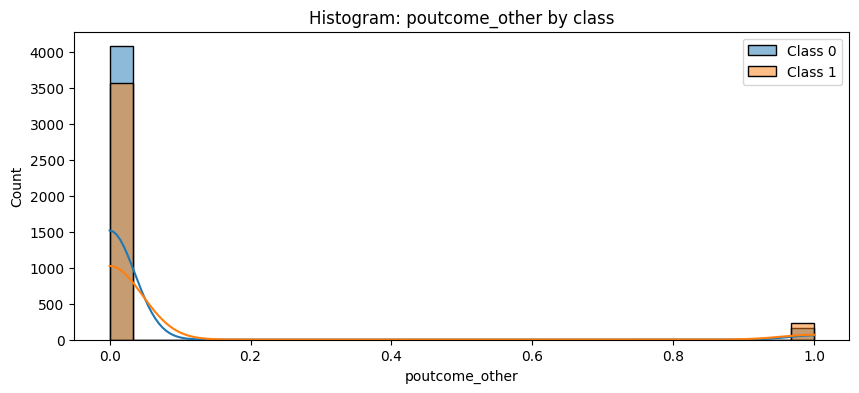

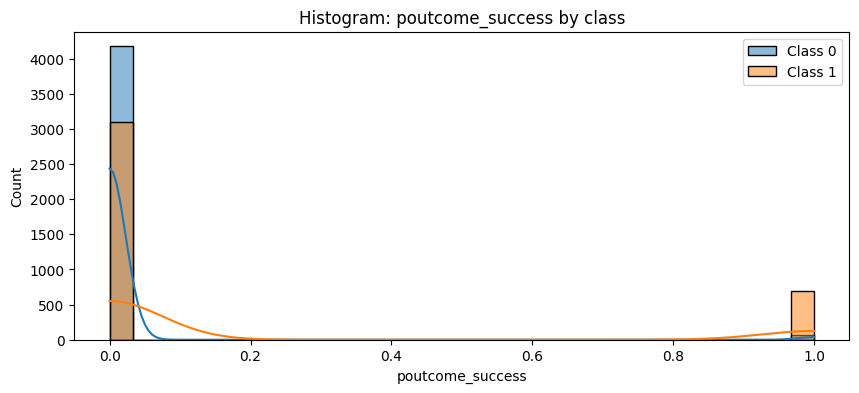

In [119]:
# Histograms by features for each class
for col in X_train.columns:
    plt.figure(figsize=(10, 4))

    # For each class
    for cls in sorted(y_train.unique()):
        sns.histplot(X_train[y_train == cls][col], kde=True, bins=30, label=f"Class {cls}", alpha=0.5)

    plt.title(f"Histogram: {col} by class")
    plt.legend()
    plt.show()

Correlation

In [121]:
df_cor = pd.concat([X_train, y_train], axis=1)

df_cor.corr().style.background_gradient(cmap='coolwarm')

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,poutcome_other,poutcome_success,deposit
age,1.000000,-0.172252,-0.007189,0.127325,-0.172370,-0.023461,-0.009006,0.080634,-0.006756,-0.002937,0.010928,0.022630,-0.065276,0.026186,0.083877,-0.037832,0.549928,-0.016424,-0.079932,-0.235195,-0.080573,0.001032,0.320185,-0.465447,0.204907,-0.010655,0.068424,0.029778
education,-0.172252,1.000000,-0.013630,0.048704,-0.091116,-0.059272,0.013486,0.040422,-0.014790,-0.027919,0.027346,0.027657,-0.371140,0.034501,-0.130589,0.518149,-0.143272,0.090684,-0.109624,-0.015667,0.042488,-0.038355,-0.130283,0.156665,-0.071578,0.021745,0.065675,0.093385
default,-0.007189,-0.013630,1.000000,-0.058911,0.018790,0.068086,0.015870,0.011996,-0.013468,0.037235,-0.032847,-0.031554,0.020529,0.016273,0.007760,0.005115,-0.012850,-0.001591,-0.022088,-0.016967,0.009237,0.012324,-0.015498,-0.000531,-0.021011,-0.013291,-0.039540,-0.047153
balance,0.127325,0.048704,-0.058911,1.000000,-0.081529,-0.084188,0.003243,0.069555,0.017776,-0.013711,0.019107,0.030836,-0.043727,0.006456,-0.009161,0.040667,0.087309,0.027979,-0.041383,-0.002347,0.000335,-0.009568,0.025804,-0.023778,0.069405,0.031101,0.050808,0.077527
housing,-0.172370,-0.091116,0.018790,-0.081529,1.000000,0.082440,-0.015684,-0.106261,0.033095,0.012114,0.070009,-0.004425,0.186723,0.022393,-0.055132,-0.076007,-0.172065,-0.020518,0.081329,-0.122625,0.014447,-0.060307,0.029159,-0.036488,-0.081642,0.007767,-0.128931,-0.199051
loan,-0.023461,-0.059272,0.068086,-0.084188,0.082440,1.000000,0.022201,0.003876,-0.002497,0.035366,-0.025018,-0.025496,0.060780,0.038403,-0.028095,-0.058066,-0.047280,0.012207,0.030707,-0.070781,0.014625,-0.039199,0.046994,-0.072377,-0.016909,-0.024114,-0.077948,-0.114704
day,-0.009006,0.013486,0.015870,0.003243,-0.015684,0.022201,1.000000,0.061514,-0.012379,0.138410,-0.077555,-0.053226,-0.023691,-0.006889,0.010663,0.018259,-0.007682,0.002207,0.007764,-0.016022,0.017733,-0.002901,-0.000951,-0.000576,0.011503,-0.012842,-0.044151,-0.055547
month,0.080634,0.040422,0.011996,0.069555,-0.106261,0.003876,0.061514,1.000000,0.006895,0.038727,-0.037325,0.005102,-0.060598,0.023142,0.014156,0.056906,0.027092,0.019815,-0.036009,-0.012501,0.022090,-0.032643,0.067041,-0.074937,0.040216,-0.025914,0.047835,0.023498
duration,-0.006756,-0.014790,-0.013468,0.017776,0.033095,-0.002497,-0.012379,0.006895,1.000000,-0.039835,-0.028734,-0.031956,0.034162,-0.011309,-0.002854,-0.022079,0.018438,0.026844,-0.002676,-0.015422,-0.002790,0.024952,-0.026880,0.021073,-0.007288,-0.000102,-0.026946,0.453515
campaign,-0.002937,-0.027919,0.037235,-0.013711,0.012114,0.035366,0.138410,0.038727,-0.039835,1.000000,-0.103592,-0.047734,0.019365,0.004607,0.012765,-0.000760,-0.033542,0.003325,0.013163,-0.019822,0.023719,-0.021601,0.045507,-0.048432,0.040756,-0.022430,-0.090894,-0.125601


In [128]:
corr_matrix = df.drop(columns=['deposit']).corr().abs()
high_corr = np.where(corr_matrix > 0.8)
high_corr = [(corr_matrix.index[x], corr_matrix.columns[y])
             for x, y in zip(*high_corr) if x != y and x < y]
print(high_corr)

[]


Dummy Classifier (Baseline model)


Train model

In [129]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

Train

In [130]:
y_pred = dummy.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.53      1.00      0.69      4239
           1       0.00      0.00      0.00      3797

    accuracy                           0.53      8036
   macro avg       0.26      0.50      0.35      8036
weighted avg       0.28      0.53      0.36      8036



Validation

In [131]:
y_pred = dummy.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.51      1.00      0.68       458
           1       0.00      0.00      0.00       435

    accuracy                           0.51       893
   macro avg       0.26      0.50      0.34       893
weighted avg       0.26      0.51      0.35       893



Test

In [132]:
y_pred = dummy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      1.00      0.69      1176
           1       0.00      0.00      0.00      1057

    accuracy                           0.53      2233
   macro avg       0.26      0.50      0.34      2233
weighted avg       0.28      0.53      0.36      2233



Confusion matrix

In [133]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1176    0]
 [1057    0]]


 One Rule

OneRule can be considered as one-depth Decision Tree

In [134]:
clf = DecisionTreeClassifier(max_depth=1, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

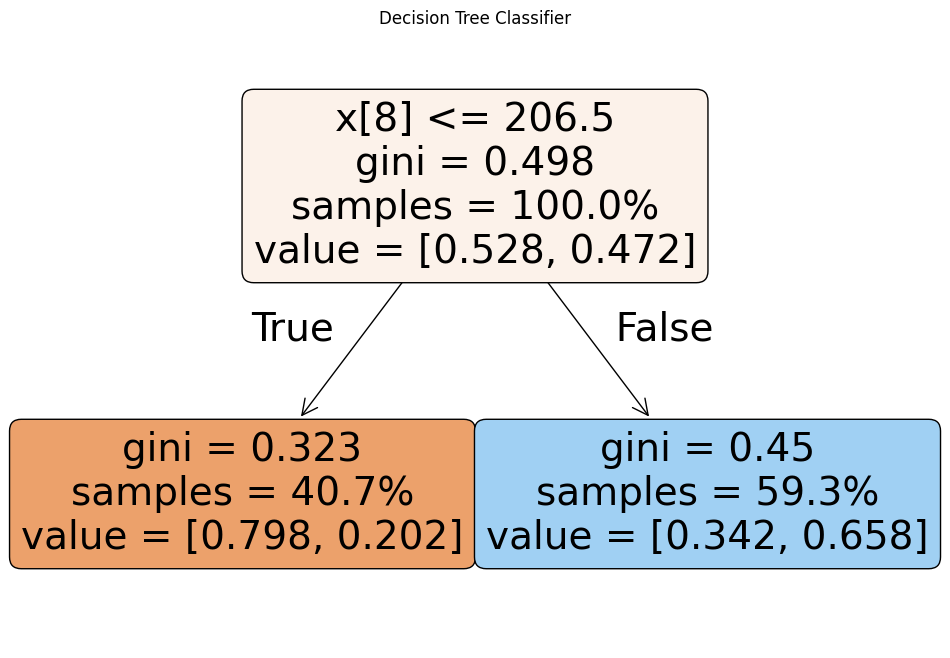

In [135]:
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, rounded=True, proportion=True)
plt.title("Decision Tree Classifier")
plt.show()

In [144]:
X_train.columns[16]

'job_retired'

job_retired is choosen as main variable

Train

In [137]:
y_pred = clf.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.62      0.70      4239
           1       0.66      0.83      0.73      3797

    accuracy                           0.72      8036
   macro avg       0.73      0.72      0.71      8036
weighted avg       0.73      0.72      0.71      8036



Validation

In [138]:
y_val_pred = clf.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.79      0.59      0.67       458
           1       0.66      0.83      0.73       435

    accuracy                           0.71       893
   macro avg       0.72      0.71      0.70       893
weighted avg       0.72      0.71      0.70       893



Test

In [139]:
y_test_pred = clf.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.78      0.60      0.68      1176
           1       0.65      0.81      0.72      1057

    accuracy                           0.70      2233
   macro avg       0.71      0.70      0.70      2233
weighted avg       0.72      0.70      0.70      2233



Confusion matrix

In [145]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[705 471]
 [201 856]]


 ## Naive Bayes
 Rescale data

In [146]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

 Model Gaussian Naive Nayes

In [147]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

Train

In [148]:
y_train_pred = nb_model.predict(X_train_scaled)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.69      0.83      0.75      4239
           1       0.75      0.58      0.66      3797

    accuracy                           0.71      8036
   macro avg       0.72      0.71      0.71      8036
weighted avg       0.72      0.71      0.71      8036



 Validation

In [149]:
y_val_pred = nb_model.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73       458
           1       0.73      0.58      0.65       435

    accuracy                           0.69       893
   macro avg       0.70      0.69      0.69       893
weighted avg       0.70      0.69      0.69       893



 Test

In [150]:
y_test_pred = nb_model.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.68      0.83      0.74      1176
           1       0.74      0.56      0.64      1057

    accuracy                           0.70      2233
   macro avg       0.71      0.69      0.69      2233
weighted avg       0.71      0.70      0.69      2233



 Confusion matrix

In [151]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[971 205]
 [464 593]]


## Decision Tree

Decision tree model

In [152]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

#Auto parameters

print("max_depth:", model.tree_.max_depth)
print("criterion:", model.criterion)
print("min_samples_split:", model.min_samples_split)
print("min_samples_leaf:", model.min_samples_leaf)

max_depth: 28
criterion: gini
min_samples_split: 2
min_samples_leaf: 1


Tune hyperparameters. Search in a grid

In [153]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(2, 36)),
    'min_samples_split': list(range(2, 21)),
    'min_samples_leaf': list(range(1, 11)),
}

param_combinations = list(itertools.product(*param_grid.values()))

results = []

best_params = None
best_score = 0

for params in tqdm(param_combinations, desc = "Processed combinations: "):
    param_dict = dict(zip(param_grid.keys(), params))

    model = DecisionTreeClassifier(**param_dict, random_state=42)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    score = f1_score(y_val, y_val_pred)

    results.append({
        'criterion': param_dict['criterion'],
        'max_depth': param_dict['max_depth'],
        'min_samples_split': param_dict['min_samples_split'],
        'min_samples_leaf': param_dict['min_samples_leaf'],
        'val_score': score
    })

    if score > best_score:
        best_score = score
        best_params = param_dict

df_results = pd.DataFrame(results)

Processed combinations: 100%|██████████| 12920/12920 [15:06<00:00, 14.25it/s]


In [154]:
print("Top 10 models:")
print(df_results.sort_values(by="val_score", ascending=False).head(10))

Top 10 models:
     criterion  max_depth  min_samples_split  min_samples_leaf  val_score
8548   entropy         12                 20                 9   0.821101
8538   entropy         12                 19                 9   0.819747
8408   entropy         12                  6                 9   0.818391
8428   entropy         12                  8                 9   0.818391
8448   entropy         12                 10                 9   0.818391
8458   entropy         12                 11                 9   0.818391
8438   entropy         12                  9                 9   0.818391
8528   entropy         12                 18                 9   0.818391
8518   entropy         12                 17                 9   0.818391
8388   entropy         12                  4                 9   0.818391


 Best model

In [155]:
best_model = DecisionTreeClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=12, min_samples_leaf=9,
                       min_samples_split=20, random_state=42)

In [156]:
best_model = DecisionTreeClassifier(criterion='entropy', max_depth=13, min_samples_leaf=6,
                       min_samples_split=16, random_state=42)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=13, min_samples_leaf=6,
                       min_samples_split=16, random_state=42)

 Train

In [157]:
y_train_pred = best_model.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4239
           1       0.88      0.88      0.88      3797

    accuracy                           0.88      8036
   macro avg       0.88      0.88      0.88      8036
weighted avg       0.88      0.88      0.88      8036



Validation

In [158]:
y_val_pred = best_model.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       458
           1       0.83      0.78      0.80       435

    accuracy                           0.81       893
   macro avg       0.82      0.81      0.81       893
weighted avg       0.82      0.81      0.81       893



Test

In [159]:
y_test_pred = best_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1176
           1       0.82      0.81      0.82      1057

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



Confusion matrix

In [160]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[989 187]
 [196 861]]


## KNN

We use rescaled data KNN model.

Hyperparameter tuning. Grid search

In [161]:
param_grid = {
    'n_neighbors': list(range(3, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
param_combinations = list(itertools.product(*param_grid.values()))
results = []

best_params = None
best_score = 0

for params in tqdm(param_combinations, desc="Processed combinations: "):
    param_dict = dict(zip(param_grid.keys(), params))

    model = KNeighborsClassifier(**param_dict)
    model.fit(X_train_scaled, y_train)

    y_val_pred = model.predict(X_val_scaled)
    score = f1_score(y_val, y_val_pred)

    # Save results
    results.append({
        'n_neighbors': param_dict['n_neighbors'],
        'weights': param_dict['weights'],
        'metric': param_dict['metric'],
        'val_score': score
    })

    # Update best parameters if the current score is better
    if score > best_score:
        best_score = score
        best_params = param_dict

df_results = pd.DataFrame(results)

Processed combinations: 100%|██████████| 56/56 [00:10<00:00,  5.51it/s]


In [162]:
print("Top 10 models:")
print(df_results.sort_values(by="val_score", ascending=False).head(10))

Top 10 models:
    n_neighbors   weights     metric  val_score
2             3  distance  euclidean   0.750000
15            9  distance  manhattan   0.749082
0             3   uniform  euclidean   0.748496
18           11  distance  euclidean   0.747847
6             5  distance  euclidean   0.746377
4             5   uniform  euclidean   0.744578
1             3   uniform  manhattan   0.742647
3             3  distance  manhattan   0.742369
19           11  distance  manhattan   0.741379
10            7  distance  euclidean   0.740291


Best model

In [163]:
best_model = KNeighborsClassifier(**best_params)
best_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

Train

In [164]:
y_train_pred = best_model.predict(X_train_scaled)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4239
           1       1.00      1.00      1.00      3797

    accuracy                           1.00      8036
   macro avg       1.00      1.00      1.00      8036
weighted avg       1.00      1.00      1.00      8036



Validation

In [165]:
y_val_pred = best_model.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       458
           1       0.79      0.72      0.75       435

    accuracy                           0.77       893
   macro avg       0.77      0.77      0.77       893
weighted avg       0.77      0.77      0.77       893



Test

In [166]:
y_test_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.74      0.81      0.77      1176
           1       0.76      0.68      0.72      1057

    accuracy                           0.75      2233
   macro avg       0.75      0.75      0.75      2233
weighted avg       0.75      0.75      0.75      2233



 Confusion matrix

In [167]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[951 225]
 [336 721]]
